In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os 
from data_loading import load_runs
from microfit.histogram import Binning, Histogram, RunHistGenerator

# Runs 4 and 5 Nue
RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit","4d_nuepresel_testsplit","5_nuepresel_testsplit"]
# RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit"]
# RUN = ["4a_nuepresel_testsplit"]
# RUN = ["4a_1shower","4b_1shower","4c_1shower","4d_1shower"]
# RUN = ["4a_1shower","4b_1shower","4c_1shower","4d_1shower","5_1shower"]
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt", "nc_pi0"],
    # truth_filtered_sets=["nue", "drt"],
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    use_bdt = True,
    load_lee=False,
    enable_cache=True,
    blinded=True,
)

Loading run 4a_nuepresel_testsplit
Loading run 4b_nuepresel_testsplit
Loading run 4c_nuepresel_testsplit
Loading run 4d_nuepresel_testsplit
Loading run 5_nuepresel_testsplit


In [3]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [4]:
from sklearn.model_selection import train_test_split

train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
train_nue, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
train_ncpi0, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

In [8]:
NUE = 'slice_orig_pass_id == 1'
NUE += ' and n_showers_contained == 1'  # Replaces 'selected'
NUE += ' and contained_fraction > 0.9'  # Replaces 'selected'
NUE += ' and shr_energy_tot_cali > 0.07'
NUE += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

ZPCRT = NUE
ZPCRT += ' and n_tracks_contained == 0'
ZPCRT += ' and crtveto != 1'

ZPLOOSENEW = ZPCRT
ZPLOOSENEW += ' and CosmicIPAll3D > 10.'
ZPLOOSENEW += ' and shrmoliereavg < 20'
ZPLOOSENEW += ' and subcluster > 5'
ZPLOOSENEW += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
ZPLOOSENEW += ' and shr_trk_len > 20'
ZPLOOSENEW += ' and CylFrac2h_1cm < 0.7'
ZPLOOSENEW += ' and shrMCSMom > 20'
ZPLOOSENEW += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'
ZPLOOSENEW += ' and diffZ > -70 and diffZ < 80'
ZPLOOSENEW += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
ZPLOOSENEW += ' and fnl > -200 and fnl < 50'

# ZPLOOSENEW += ' and slcng2hip < 40'
# ZPLOOSENEW += ' and slcng2mip < 50'
# ZPLOOSENEW += ' and slcng2mcl < 40'
# ZPLOOSENEW += ' and clung2hip < 50'

ZPBDTNEW = ZPLOOSENEW
ZPBDTNEW += ' and pi0_score > 0.95'
ZPBDTNEW += ' and nonpi0_score > 0.975'
# ZPBDTNEW += ' and bkg_score > 0.6'

# Selection 1b Cuts
# ZPBDTNEW += 'and clung2hip < 20'
# ZPBDTNEW += ' and CosmicDirAll3D > -0.95'
# ZPBDTNEW += ' and CosmicIPAll3D > 12'

# Selection 1d Cuts
# ZPBDTNEW += ' and ng2hip_r10cm < 20'
# ZPBDTNEW += ' and clung2hip < 20'
# ZPBDTNEW += ' and nhits_r3cm'
# ZPBDTNEW += ' and CosmicDirAll3D > -0.95'
# ZPBDTNEW += ' and normdiffZ < 0.6'
# # Selection 1e Cuts
# ZPBDTNEW += ' and secondshower_Y_vtxdist > 5'
# ZPBDTNEW += ' and DeltaRMS2h > 1.5'
# ZPBDTNEW += ' and CosmicIPAll3D < 250'
# Selection 1f cuts
ZPBDTNEW += ' and slcng2hip < 20'
# Selection 1g cuts
ZPBDTNEW += ' and nhits_r3cm < 75'
ZPBDTNEW += ' and CosmicDirAll3D > -0.95'
ZPBDTNEW += ' and normdiffZ < 0.6'
ZPBDTNEW += ' and diffZ < 50'
ZPBDTNEW += ' and DeltaRMS2h > 1.5'

# Selection 2b Cuts
# ZPBDTNEW += ' and trkfit > 0.05'
# ZPBDTNEW += ' and clung2hip < 20'

# Selection 2d Cuts
# ZPBDTNEW += ' and tksh_distance > 20'
# ZPBDTNEW += ' and trkfit > 0.05'
# ZPBDTNEW += ' and secondshower_V_vtxdist < 110'
# ZPBDTNEW += ' and clung2hip < 20'

nuepreselection = NUE
preselection = ZPCRT
selection = ZPLOOSENEW
bdtselection = ZPBDTNEW

nue = test_nue
nu = test_nu
drt = test_dirt
ncpi0 = test_ncpi0
ext = test_ext

In [9]:
import numpy as np
import matplotlib.pyplot as plt 

def Eff(df,var,query,acceptance,bin_edges,absval=False):
    #print acceptance
    bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
    bins = []
    bin_eff = []
    bin_err = []
    for i in range(len(bin_centers)):
        binmin = bin_edges[i]
        binmax = bin_edges[i+1]
        bincut = '%s > %f and %s < %f'%(var,binmin,var,binmax)
        if (absval == True):
            bincut = '(%s > %f and %s < %f) or (%s > -%f and %s < -%f)'%(var,binmin,var,binmax,var,binmax,var,binmin)
        if (acceptance != ''): bincut += ' and %s'%acceptance
        #print bincut
        df_tmp =  df.query(bincut, engine='python') # cut on bin range for desired var.
        df_sub = df_tmp.query(query, engine='python') # apply constrain 
        if (df_tmp.shape[0] == 0): continue
        eff = df_sub.shape[0] / float( df_tmp.shape[0] )
        err = np.sqrt( eff*(1-eff)/df_tmp.shape[0] )
        bin_eff.append( eff )
        bin_err.append( err )
        bins.append(bin_centers[i])
        # print('eff = %.02f @ bin = %.02f'%(eff,bin_centers[i]))
    return np.array(bins),np.array(bin_eff),np.array(bin_err)

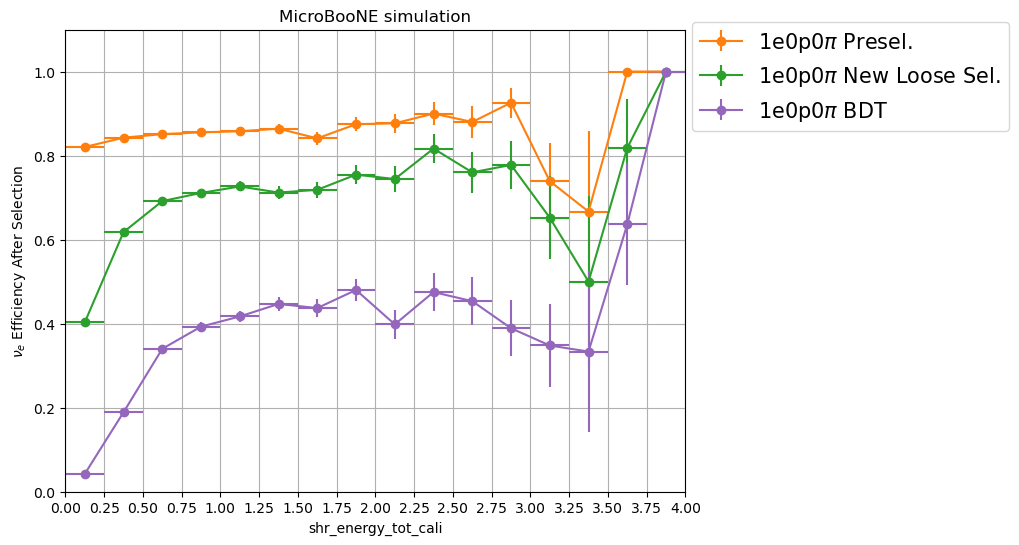

In [10]:
fig, ax = plt.subplots(figsize=(8,6))

# VAR = 'nu_e' #'_pi0_e'
VAR = 'shr_energy_tot_cali'
# VAR = 'reco_e'
# VAR = 'pi0_score'
# VAR = 'nonpi0_score'
# VAR = 'bkg_score'

# bin_edges = np.linspace(0.15,1.55,8)        # nu_e binning
bin_edges = np.linspace(0, 4, 17)     # shr_energy_tot_cali binning
# bin_edges = np.linspace(0.15, 2.95, 9)     # reco_e binning
# bin_edges = np.linspace(0, 1, 11)          # BDT score binning
# print(bin_edges)

ACCEPTANCE = 'isVtxInFiducial == 1 and truthFiducial == 1 and npi0==0 and npion==0 and nproton==0'
ACCEPTANCE += ' and '
ACCEPTANCE += nuepreselection
VTX = ' and dr_s<1.0'

colors = ['C1','C2','C4']

lables = ['1e0p0$\pi$ Presel.','1e0p0$\pi$ New Loose Sel.','1e0p0$\pi$ BDT']
for i,q in enumerate([preselection,selection,bdtselection]):
    fmt = 'o-'
    centers,vals,errs = Eff(nue,VAR,q,ACCEPTANCE,bin_edges)
    ax.errorbar(centers,vals,yerr=errs,xerr=(bin_edges[1]-bin_edges[2])/2,fmt=fmt,label=lables[i],color=colors[i])

# lables = ['1ep0$\pi$ Presel, $\Delta_{VTX}$<1 cm','Loose, $\Delta_{VTX}$<1 cm','BDT, $\Delta_{VTX}$<1 cm']
# for i,q in enumerate([preselection,selection,bdtselection]):
#     fmt = 'o:'
#     centers,vals,errs = Eff(nue,VAR,q+VTX,ACCEPTANCE+VTX,bin_edges)
#     ax.errorbar(centers,vals,yerr=errs,xerr=(bin_edges[1]-bin_edges[2])/2,label=lables[i],fmt=fmt,color=colors[i],mfc = 'w')

ax.set_xlabel(VAR)
ax.set_ylabel(r'$\nu_e$ Efficiency After Selection')
ax.set_xticks(bin_edges)
ax.set_ylim(0.,1.1)
#ax.set_ylim(0.,0.15)
ax.set_xlim(bin_edges[0],bin_edges[-1])
plt.legend(ncol=1, prop={'size': 15}, loc=(1.01,0.78))
# plt.legend(ncol=2, prop={'size': 15}, loc=(0,0.75))
#plt.title("dr(shr vtx reco, vtx mc sce)<1.0")
plt.title("MicroBooNE simulation")
plt.grid(True)
#plt.yscale('log')
plt.show()
#fig.savefig(ls.plots_path+"eff_1eNp_cut_bdt.pdf")
# fig.savefig(ls.plots_path+"eff_1eNp_vtx1cm_presel.pdf")

In [9]:
cutlist = []
# cutlist.append({"cut": "slice_orig_pass_id == 1", "name": "slice_orig_pass_id"})
# cutlist.append({"cut": "contained_fraction >= 0.9", "name": "contained_fraction"})
# cutlist.append({"cut": "n_showers_contained == 1", "name": "n_showers_contained"})
# cutlist.append({"cut": "shr_energy_tot_cali > 0.07", "name": "shr_energy_tot_cali"})
# cutlist.append({"cut": "( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)", "name": "optical filter"})

cutlist.append({"cut": "n_tracks_contained == 0", "name": "n_tracks_contained"})
cutlist.append({"cut": "crtveto != 1", "name": "crtveto"})

cutlist.append({"cut": 'CosmicIPAll3D > 10.', "name": "CosmicIPAll3D"})
cutlist.append({"cut": 'shrmoliereavg < 20', "name": "shrmoliereavg"})
cutlist.append({"cut": 'subcluster > 5', "name": "subcluster"})
cutlist.append({"cut": 'shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100', "name": "shr_trk_sce_start_y"})
cutlist.append({"cut": 'shr_trk_len > 20', "name": "shr_trk_len"})
cutlist.append({"cut": 'n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9)', "name": "track cuts"})

cutlist.append({"cut": 'diffZ > -70 and diffZ < 80', "name": "diffZ"})
cutlist.append({"cut": 'normdiffZ > -0.75 and normdiffZ < 0.75', "name": "normdiffZ"})
cutlist.append({"cut": 'fnl > -200 and fnl < 50', "name": "fnl"})

cutlist.append({"cut": 'slcng2hip < 40', "name": "slcng2hip"})
cutlist.append({"cut": 'slcng2mip < 50', "name": "slcng2mip"})
cutlist.append({"cut": 'slcng2mcl < 40', "name": "slcng2mcl"})
cutlist.append({"cut": 'clung2hip < 50', "name": "clung2hip"})

# cutlist.append({"cut": 'pi0_score > 0.6', "name": "pi0_score"})
# cutlist.append({"cut": 'nonpi0_score > 0.6', "name": "nonpi0_score"})
# cutlist.append({"cut": 'bkg_score > 0.6', "name": "bkg_score"})

In [10]:
QUERY = NUE
# QUERY = ZPCRT
# QUERY = ZPLOOSENEW

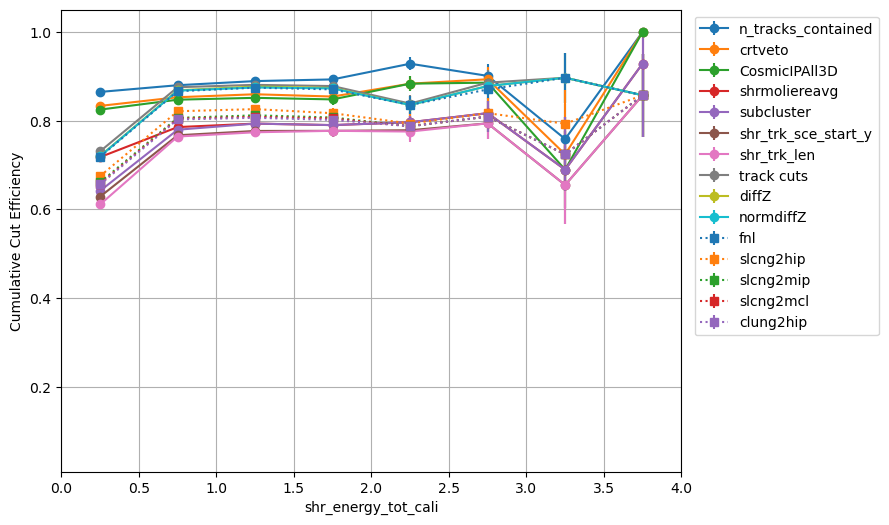

In [11]:
#fig = plt.figure(figsize=(8,6))
fig, ax = plt.subplots(figsize=(8,6))

# bin_edges = np.linspace(0.15,1.55,8)        # nu_e binning
bin_edges = np.linspace(0, 4, 9)     # shr_energy_tot_cali binning
# bin_edges = np.linspace(0.15, 2.95, 9)     # reco_e binning
# bin_edges = np.linspace(0, 1, 11)          # BDT score binning

# VAR = 'nu_e' #'_pi0_e'
VAR = 'shr_energy_tot_cali'
# VAR = 'reco_e'
# VAR = 'pi0_score'
# VAR = 'nonpi0_score'
# VAR = 'bkg_score'

ACCEPTANCE = 'isVtxInFiducial == 1 and truthFiducial == 1 and npi0==0 and npion==0 and nproton==0'
#ACCEPTANCE += ' and dr_s<1.0'

for c in range(0,len(cutlist)):
    if c==0: cut = cutlist[c]["cut"]
    else: cut = cut+" and "+cutlist[c]["cut"]
    fmt = 'o-'
    if c>9: fmt = 's:'
    centers,vals,errs = Eff(nue,VAR,cut,ACCEPTANCE,bin_edges)
    ax.errorbar(centers,vals,yerr=errs,fmt=fmt,label=cutlist[c]["name"])
    # print(cutlist[c]["name"])
    #print(vals[0])
ax.set_xlabel(VAR)
ax.set_ylabel('Cumulative Cut Efficiency')
ax.set_xticks(bin_edges)
ax.set_ylim(0.01,1.05)
ax.set_xlim(bin_edges[0],bin_edges[-1])
plt.legend(bbox_to_anchor=(1.01,1.), loc='upper left', ncol=1)
#plt.title("dr(shr vtx reco, vtx mc sce)<1.0")
plt.grid(True)
#plt.yscale('log')
plt.show()


In [7]:
# def Pur(df1, df2, df3, df4, df5, var, query, acceptance, bin_edges, absval=False):
#     bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
#     bins = []
#     bin_pur = []
#     bin_err = []
#     for i in range(len(bin_centers)):
#         binmin = bin_edges[i]
#         binmax = bin_edges[i+1]
#         bincut = '%s > %f and %s < %f'%(var,binmin,var,binmax)
#         if (absval == True):
#             bincut = '(%s > %f and %s < %f) or (%s > -%f and %s < -%f)'%(var,binmin,var,binmax,var,binmax,var,binmin)
#         if (acceptance != ''): bincut += ' and %s'%acceptance
#         df1_tmp = nue.query(bincut, engine='python')
#         df2_tmp = df2.query(bincut, engine='python')
#         df3_tmp = df3.query(bincut, engine='python')
#         df4_tmp = df4.query(bincut, engine='python')
#         df5_tmp = df5.query(bincut, engine='python')
#         df1_sub = df1_tmp.query(query, engine='python')
#         df2_sub = df2_tmp.query(query, engine='python')
#         df3_sub = df3_tmp.query(query, engine='python')
#         df4_sub = df4_tmp.query(query, engine='python')
#         df5_sub = df5_tmp.query(query, engine='python')
#         # print("nue: ", df1_sub.shape[0])
#         # print("mc", df2.shape[0])
#         # print("dirt", df3.shape[0])
#         # print("ncpi0", df4.shape[0])
#         # print("ext", df5.shape[0])
#         # print("df_sub shape[0] sum: ", df1_sub.shape[0] + df2_sub.shape[0] + df3_sub.shape[0] + df4_sub.shape[0] + df5_sub.shape[0])
#         # if (nue_tmp.shape[0] == 0): continue
#         if (df1_sub.shape[0] + df2_sub.shape[0] + df3_sub.shape[0] + df4_sub.shape[0] + df5_sub.shape[0] == 0): continue
#         pur = df1_sub.shape[0] / float (df1_sub.shape[0] + df2_sub.shape[0] + df3_sub.shape[0] + df4_sub.shape[0] + df5_sub.shape[0])
#         print("purity: ", pur)
#         err = np.sqrt( pur*(1-pur)/ (df1_sub.shape[0] + df2_sub.shape[0] + df3_sub.shape[0] + df4_sub.shape[0] + df5_sub.shape[0]))
#         bin_pur.append(pur)
#         bin_err.append(err)
#         bins.append(bin_centers[i])
#     return np.array(bins), np.array(bin_pur), np.array(bin_err)

[0.  0.5 1.  1.5 2.  2.5 3.  3.5 4. ]
1e0p0$\pi$ Presel
purity:  0.9781962338949455
purity:  0.9944093339815265
purity:  0.9985089463220675
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0
New 0p Loose Sel.
purity:  0.9891782211701048
purity:  0.9977206121784435
purity:  0.9993243243243243
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0
BDT
purity:  0.9988137603795967
purity:  0.9994761655316919
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0
purity:  1.0


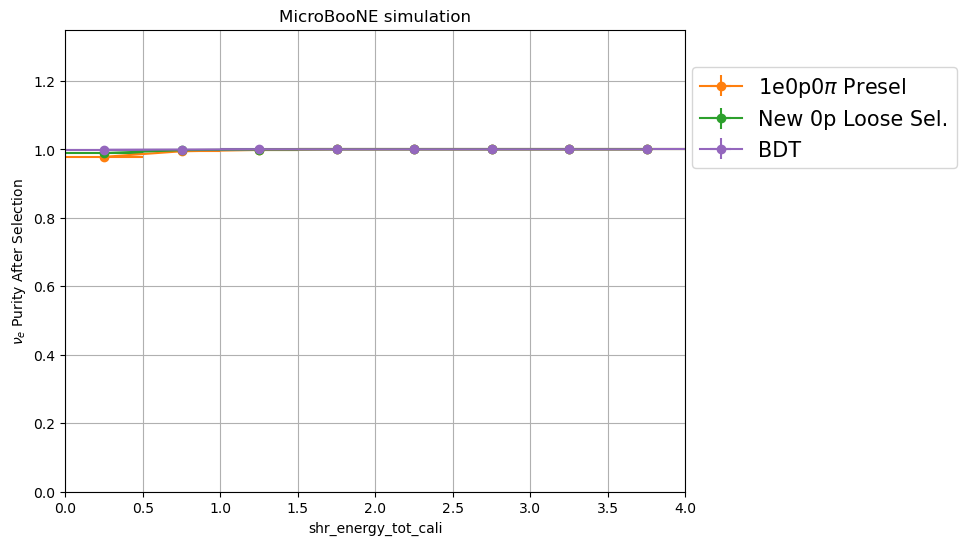

In [ ]:
# fig, ax = plt.subplots(figsize=(8,6))

# # VAR = 'nu_e' #'_pi0_e'
# VAR = 'shr_energy_tot_cali'
# # VAR = 'reco_e'
# # VAR = 'pi0_score'
# # VAR = 'nonpi0_score'
# # VAR = 'bkg_score'

# # bin_edges = np.linspace(0.15,1.55,8)        # nu_e binning
# # bin_edges = np.linspace(0, 4, 17)     # shr_energy_tot_cali binning
# bin_edges = np.linspace(0, 4, 9)     # shr_energy_tot_cali binning
# # bin_edges = np.linspace(0.15, 2.95, 9)     # reco_e binning
# # bin_edges = np.linspace(0, 1, 11)          # BDT score binning
# print(bin_edges)

# ACCEPTANCE = 'isVtxInFiducial == 1 and truthFiducial == 1 and npi0==0 and npion==0 and nproton==0'
# ACCEPTANCE += ' and '
# ACCEPTANCE += nuepreselection
# VTX = ' and dr_s<1.0'

# colors = ['C1','C2','C4']

# lables = ['1e0p0$\pi$ Presel','New 0p Loose Sel.','BDT']
# for i,q in enumerate([preselection,selection,bdtselection]):
# # for i,q in enumerate([preselection,selection]):
#     fmt = 'o-'
#     print(lables[i])
#     centers,vals,errs = Pur(nue,nu,drt,ncpi0,ext,VAR,q,ACCEPTANCE,bin_edges)
#     ax.errorbar(centers,vals,yerr=errs,xerr=(bin_edges[1]-bin_edges[2])/2,fmt=fmt,label=lables[i],color=colors[i])

# # lables = ['1ep0$\pi$ Presel, $\Delta_{VTX}$<1 cm','Loose, $\Delta_{VTX}$<1 cm','BDT, $\Delta_{VTX}$<1 cm']
# # for i,q in enumerate([preselection,selection,bdtselection]):
# #     fmt = 'o:'
# #     centers,vals,errs = Eff(nue,VAR,q+VTX,ACCEPTANCE+VTX,bin_edges)
# #     ax.errorbar(centers,vals,yerr=errs,xerr=(bin_edges[1]-bin_edges[2])/2,label=lables[i],fmt=fmt,color=colors[i],mfc = 'w')

# ax.set_xlabel(VAR)
# ax.set_ylabel(r'$\nu_e$ Purity After Selection')
# ax.set_xticks(bin_edges)
# ax.set_ylim(0.,1.35)
# #ax.set_ylim(0.,0.15)
# ax.set_xlim(bin_edges[0],bin_edges[-1])
# plt.legend(ncol=1, prop={'size': 15}, loc=(1.01, 0.7))
# # plt.legend(ncol=2, prop={'size': 15}, loc=(0,0.75))
# #plt.title("dr(shr vtx reco, vtx mc sce)<1.0")
# plt.title("MicroBooNE simulation")
# plt.grid(True)
# #plt.yscale('log')
# plt.show()
# #fig.savefig(ls.plots_path+"eff_1eNp_cut_bdt.pdf")
# # fig.savefig(ls.plots_path+"eff_1eNp_vtx1cm_presel.pdf")

In [ ]:
# rundata["mc"]=test_nu
# rundata["nue"]=test_nue
# rundata["drt"]=test_dirt
# rundata["nc_pi0"]=test_ncpi0
# rundata["ext"]=test_ext

# v = ("shr_energy_tot_cali", 10, (0, 4), "shr_energy_tot_cali")

# preselection = 'ZPCRT'
# selection = 'ZPLOOSENEW'

# binning_def = v
# binning = Binning.from_config(*binning_def)
# binning.label = preselection
# binning.set_selection(selection, preselection)

# signal_generator = RunHistGenerator(
#     rundata,
#     binning,
#     data_pot=data_pot,
# )

# from microfit.run_plotter import RunHistPlotter

# plotter = RunHistPlotter(signal_generator)

# print(plotter.category_column)

# ax = plotter.plot(
#     category_column="category",
#     include_multisim_errors=False,
#     add_ext_error_floor=False,
#     show_data_mc_ratio=False,
#     show_chi_square=False,
#     show_total=False,           # Get rid of uncertainty
#     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
# )

# # my_plotter = plotter.Plotter(samples, weights, pot=pot)
# # def Pur(my_plotter,VARIABLE,QUERY,BINS,RANGE):
# #     fig, ax1, ax2, stack, labls, exty = my_plotter.plot_variable(
# #         VARIABLE,   
# #         query=QUERY,
# #         kind="event_category",
# #         draw_sys=False,
# #         stacksort=3,
# #         title="my_xaxis",
# #         bins=BINS,
# #         range=RANGE,
# #     )
# #     nuel = -1
# #     for i, l in enumerate(labls):
# #         if 'nu_e' in l and 'Np' in l: 
# #             nuel = i
# #             break
# #     plt.close(fig)
# #     return (stack[0][nuel]-stack[0][nuel-1])/(stack[0][nuel]+exty)

AttributeError: 'RunHistPlotter' object has no attribute 'category_column'